# Problem Solution Pipeline

In [256]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import duckdb
import logging
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

## Data preparation: load data files into a database with DuckDB using python

In [257]:
# Data preparation: load data files into a database with DuckDB using python
# Data was created as through the data_load_process.ipynb notebook, which processed the raw data files and saved them as Parquet files. 
# Here, we are using those parquet files and structuring them into a relational database using DuckDB, separating fires, causes, weather, and time into normalized tables.

logging.basicConfig(filename='pipeline.log', level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

def connect_db():
    try:
        # Connect to local DuckDB instance
        con = duckdb.connect(database='california_fires.duckdb', read_only=False)
        logging.info("Connected to DuckDB database 'california_fires.duckdb'")
        print("Connected to DuckDB database 'california_fires.duckdb'")

        # Drop tables if they already exist
        con.execute("DROP TABLE IF EXISTS Fires")
        con.execute("DROP TABLE IF EXISTS Causes")
        con.execute("DROP TABLE IF EXISTS Time")
        con.execute("DROP TABLE IF EXISTS Weather")
        logging.info("Existing tables dropped if they existed.")

        # Load Parquet files into DuckDB
        con.execute("CREATE TABLE Fires AS SELECT * FROM 'parquet_files/fires.parquet'")
        con.execute("CREATE TABLE Causes AS SELECT * FROM 'parquet_files/causes.parquet'")
        con.execute("CREATE TABLE Time AS SELECT * FROM 'parquet_files/time.parquet'")
        con.execute("CREATE TABLE Weather AS SELECT * FROM 'parquet_files/weather.parquet'")
        logging.info("Parquet files loaded into DuckDB tables successfully.")
        print("Parquet files loaded into DuckDB tables successfully.")

    except Exception as e:
        logging.error(f"Error connecting to DuckDB or loading data: {e}")
        print(f"Error connecting to DuckDB or loading data: {e}")

if __name__ == "__main__":
    connect_db()

Connected to DuckDB database 'california_fires.duckdb'
Parquet files loaded into DuckDB tables successfully.


## Query: demonstrate queries to prepare your solution

In [258]:
# Query: demonstrate queries to prepare your solution
# Prepare the data for analysis by creating a view that joins the relevant tables together, so we can easily query the combined data for our analysis and visualizations.
def prepare_data():
    try:
        con = duckdb.connect(database='california_fires.duckdb', read_only=False)
        logging.info("Connected to DuckDB database for data preparation.")

        # Create a view that joins the relevant tables together based on their foreign key relationships
        con.execute("""
            CREATE OR REPLACE VIEW fire_data AS
            SELECT 
                f.fire_id, f.collection_method, f.acres_burned, f.shape_area, f.shape_length, f.duration_days,
                c.cause_name, c.cause_type, 
                t.year, t.month, t.decade, t.day_of_year, t.week, t.season, t.is_peak_fire_season,
                w.lat, w.lon, w.temp_max, w.temp_min, w.precip, w.wind_speed
            FROM Fires f
            JOIN Causes c ON f.cause_id = c.cause_id
            JOIN Time t ON f.time_id = t.time_id
            JOIN Weather w ON f.weather_id = w.weather_id
        """)
        # Pull the view into a pandas DataFrame
        fire_data_df = con.execute("SELECT * FROM fire_data").df()

        logging.info("View 'fire_data' created successfully and data pulled into pandas DataFrame.")
        print("View 'fire_data' created successfully and data pulled into pandas DataFrame.")

        return fire_data_df

    except Exception as e:
        logging.error(f"Error preparing data: {e}")
        print(f"Error preparing data: {e}")

if __name__ == "__main__":
    fire_data_df = prepare_data()

View 'fire_data' created successfully and data pulled into pandas DataFrame.


In [259]:
# Function to explore the data: summary statistics and correlations to understand the relationships between variables and identify patterns in the data. 
# The correlations show if there were any variables that may cause data leakage, and are derived after wildfire area is collected, which we would want to exclude from our model. 
def explore_data(fire_data_df):
    try:
        logging.info("Starting data exploration")
        print("Starting data exploration\n")

        con = duckdb.connect(database='california_fires.duckdb', read_only=False)
        logging.info("Connected to DuckDB database for data exploration.")

        # Register pandas DataFrame
        con.register("fire_data_df", fire_data_df)

        # Summary statistics
        num_sum = con.execute("""SELECT 
                              MIN(acres_burned) AS min_acres,
                              MAX(acres_burned) AS max_acres,
                              AVG(acres_burned) AS avg_acres,
                              STDDEV(acres_burned) AS std_acres
                              FROM fire_data_df;""").df()
        print("\n--- Summary Statistics ---")
        print(num_sum.to_string(index=False))

        # Examine variables highly correlated with acres burned
        # Correlation between acres burned and shape area
        corr = con.execute("""SELECT corr(shape_area, acres_burned) AS corr_shape_area FROM fire_data_df;""").df()
        print("\n--- Correlation between acres burned and shape area---")
        print(corr.to_string(index=False))

        # Correlation between acres burned and shape length
        corr1 = con.execute("""SELECT corr(shape_length, acres_burned) AS corr_shape_area FROM fire_data_df;""").df()
        print("\n--- Correlation between acres burned and shape length---")
        print(corr1.to_string(index=False))

        # Correlation between acres burned and duration days
        corr2 = con.execute("""SELECT corr(duration_days, acres_burned) AS corr_shape_area FROM fire_data_df;""").df()
        print("\n--- Correlation between duration days and shape area---")
        print(corr2.to_string(index=False))

        # Fire activity over time
        fire_activity = con.execute("""SELECT decade, 
                                    COUNT(*) AS num_fires,
                                    AVG(acres_burned) AS avg_acres FROM fire_data_df
                                    GROUP BY decade
                                    ORDER BY decade;""").df()
        print("\n--- Fire Activity Over Time ---")
        print(fire_activity.to_string(index=False))

        logging.info("Data exploration completed successfully.")
        print("\nData exploration completed successfully.")

    except Exception as e:
        logging.error(f"Error exploring data: {e}")
        print(f"Error exploring data: {e}")

if __name__ == "__main__":
    explore_data(fire_data_df)

Starting data exploration


--- Summary Statistics ---
 min_acres  max_acres   avg_acres    std_acres
  0.001171   963405.4 1661.393553 17348.148821

--- Correlation between acres burned and shape area---
 corr_shape_area
        0.998824

--- Correlation between acres burned and shape length---
 corr_shape_area
        0.917994

--- Correlation between duration days and shape area---
 corr_shape_area
        0.212102

--- Fire Activity Over Time ---
 decade  num_fires   avg_acres
   1980        932 1701.169518
   1990        692 1982.261491
   2000       1495 1226.415471
   2010       2004 1511.355335
   2020       1413 2151.030502

Data exploration completed successfully.


In [260]:
fire_data_df.head()

,fire_id,collection_method,acres_burned,shape_area,shape_length,duration_days,cause_name,cause_type,year,month,...,day_of_year,week,season,is_peak_fire_season,lat,lon,temp_max,temp_min,precip,wind_speed
0,2,Mixed Collection Methods,14056.2600,8.336393e+07,104933.207224,23.0,Unknown/Unidentified,Unknown,2025,1,...,8,2,Winter,0,34.325791,-118.224360,8.5,1.3,0.0,38.7
1,4,GPS Air,998.7378,5.919678e+06,15602.004849,26.0,Unknown/Unidentified,Unknown,2025,1,...,9,2,Winter,0,34.457516,-119.083686,20.7,6.8,0.0,12.1
2,6,Mixed Collection Methods,347.7042,2.073567e+06,11177.246538,3.0,Unknown/Unidentified,Unknown,2025,1,...,8,2,Winter,0,34.325791,-118.224360,8.5,1.3,0.0,38.7
3,7,Mixed Collection Methods,429602.8000,2.976278e+09,543809.449228,45.0,Arson,Human,2024,7,...,206,30,Summer,1,39.689387,-121.604268,40.0,29.2,0.0,24.4
4,13,Infrared,23526.3500,1.377907e+08,106263.443450,27.0,Equipment Use,Human,2024,9,...,253,37,Fall,1,33.699656,-117.758946,35.9,23.2,0.0,16.3


In [261]:
fire_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6536 entries, 0 to 6535
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   fire_id              6536 non-null   int64  
 1   collection_method    4695 non-null   object 
 2   acres_burned         6536 non-null   float64
 3   shape_area           6536 non-null   float64
 4   shape_length         6536 non-null   float64
 5   duration_days        4675 non-null   float64
 6   cause_name           6536 non-null   object 
 7   cause_type           6536 non-null   object 
 8   year                 6536 non-null   int32  
 9   month                6536 non-null   int32  
 10  decade               6536 non-null   int32  
 11  day_of_year          6536 non-null   int32  
 12  week                 6536 non-null   uint32 
 13  season               6536 non-null   object 
 14  is_peak_fire_season  6536 non-null   int64  
 15  lat                  6536 non-null   f

## Solution analysis: Implement a model

In [262]:
# Solution analysis: Implement a model
# For the analysis, I will implement 2 models and compare their performance: a Random Forest regression model and a Linear Regression model. 
# This will allow us to see if a more complex model like Random Forest provides better predictive performance compared to a simpler linear model, and then choose the final model based on the evaluation.
# The goal is to predict the acres burned based on the various features in the dataset. This will help us understand which factors are most influential in determining the severity of a fire.

# Define target and features
y = np.log1p(fire_data_df['acres_burned'])  # Log-transform the target variable to handle skewness
X = fire_data_df.drop(columns=['acres_burned', 'fire_id', 'shape_area', 'shape_length', 'duration_days'])  # Features (take away features that may be directly related to burn size or features that are created AFTER the fire starts)

# Preprocess data based on column types
# Identify column types
categorical_cols = [col for col in ['collection_method', 'cause_name', 'cause_type', 'season'] if col in X.columns]
numerical_cols = [col for col in X.columns if col not in categorical_cols]
numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), # Handle missing values by filling with median
                             ('scaler', StandardScaler())]) # Scale numeric features for better performance 
categorical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), # Handle missing values by filling with most frequent value
                                ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))]) # Convert categorical variables into numerical format using one-hot encoding
preprocess_pipeline = ColumnTransformer([('num', numeric_pipeline, numerical_cols),
                                         ('cat', categorical_pipeline, categorical_cols)])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=888)

# Random Forest Model
# Create Pipeline
pipeline_rf = Pipeline([('preprocessor', preprocess_pipeline), # Preprocess the data
                        ('rf', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42))]) # Random Forest Regressor

# Fit the model
pipeline_rf.fit(X_train, y_train)
# Predict and evaluate the model
y_pred_rf = pipeline_rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)
print(f"Random Forest Regression RMSE: {rf_rmse}")
print(f"Random Forest Regression R^2: {rf_r2}")

# Cross Validation for Random Forest
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf_cv_scores = cross_val_score(pipeline_rf, X, y, cv=kf, scoring='neg_mean_squared_error')
rf_cv_rmse_scores = np.sqrt(-rf_cv_scores)
print(f"Random Forest Cross-Validation RMSE Scores: {rf_cv_rmse_scores}")
print(f"Random Forest Cross-Validation RMSE Mean: {rf_cv_rmse_scores.mean()}")

# Linear Regression Model
# Create Pipeline
pipeline_lr = Pipeline([('preprocessor', preprocess_pipeline), # Preprocess the data
                         ('lr', LinearRegression())]) # Linear Regression
# Fit the model
pipeline_lr.fit(X_train, y_train)
# Predict and evaluate the model
y_pred_lr = pipeline_lr.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)
print(f"Linear Regression RMSE: {lr_rmse}")
print(f"Linear Regression R^2: {lr_r2}")

# Cross Validation for Linear Regression
lr_cv_scores = cross_val_score(pipeline_lr, X, y, cv=kf, scoring='neg_mean_squared_error')
lr_cv_rmse_scores = np.sqrt(-lr_cv_scores)
print(f"Linear Regression Cross-Validation RMSE Scores: {lr_cv_rmse_scores}")
print(f"Linear Regression Cross-Validation RMSE Mean: {lr_cv_rmse_scores.mean()}")

Random Forest Regression RMSE: 1.613886841750913
Random Forest Regression R^2: 0.4684458517264437
Random Forest Cross-Validation RMSE Scores: [1.67253799 1.65744665 1.74665264 1.67412531 1.67515332]
Random Forest Cross-Validation RMSE Mean: 1.6851831814638558
Linear Regression RMSE: 1.8002162917044966
Linear Regression R^2: 0.33862050582969316
Linear Regression Cross-Validation RMSE Scores: [1.90898754 1.82673312 1.93770646 1.87890201 1.86451517]
Linear Regression Cross-Validation RMSE Mean: 1.883368856391984


In [263]:
print("\nModel Comparison:")
print(f"Random Forest RMSE: {rf_rmse:.3f}, R-squared: {rf_r2:.3f}")
print(f"Linear Regression RMSE: {lr_rmse:.3f}, R-squared: {lr_r2:.3f}")

# Final model selection
print("\nBased on the RMSE and R-squared values, the Random Forest Regression model performs better than the Linear Regression model in predicting acres burned. \nTherefore, we will select the Random Forest model as our final model for predictions.")

# Revert log transformation to acres burned for better interpretability of predictions
y_pred_rf_exp = np.expm1(y_pred_rf)

# Mean Absolute Error in original scale for better interpretability of predictions
rf_mae_exp = mean_absolute_error(np.expm1(y_test), y_pred_rf_exp)
print(f"\nRandom Forest Regression MAE: {rf_mae_exp:.2f} acres difference of predicted vs actual")


Model Comparison:
Random Forest RMSE: 1.614, R-squared: 0.468
Linear Regression RMSE: 1.800, R-squared: 0.339

Based on the RMSE and R-squared values, the Random Forest Regression model performs better than the Linear Regression model in predicting acres burned. 
Therefore, we will select the Random Forest model as our final model for predictions.

Random Forest Regression MAE: 1149.06 acres difference of predicted vs actual


## Analysis rationale

Two models, random forest and linear regression, were implemented to predict acres burned based on the dataset. The final model was chosen based on its performance metrics: mean squared error and R-squared value. 

In the process of building the model, the dataset was first preprocessed to handle any missing values and to encode categorical variables. Categorical variables were transformed using one-hot encoding to convert them into numeric format suitable for the models. Feature selection was performed to identify the most relevant features for the prediction task. Specifically, `acres_burned` was set as the target variable, while the following features were dropped as they may directly be related to the target variable and could lead to data leakage: `shape_area`, `shape_length`, and `duration_days`. These variables are outcomes or directly derived from fire size, so including them would allow the model to indirectly “see the answer.” `fire_id` was also dropped as it is an identifier and does not provide predictive value. Missing values were imputed using the median for numerical values to ensure that the imputation does not skew the data distribution. The target variable was log-transformed to address skewness in the distribution of acres burned, which can help improve the performance of the models.

After preprocessing, the dataset was split into training and testing sets to evaluate the model's performance on unseen data. Both models were trained on the training set, and their predictions were evaluated on the testing set using root mean squared error and R-squared metrics. Root mean squared error was chosen as it provides a measure of the average magnitude of the errors in the predictions, while R-squared indicates how well the model explains the variance in the target variable.

Finally, as the random forest model showed better performance metrics compared to the linear regression model, it was selected as the final model for predicting acres burned. The random forest model captures nonlinear relationships and interactions between features, which likely contributed to its better performance over linear regression. The random forest model's will be used for further interpretation of feature importance, and any visualizations, to understand which factors contribute most to the prediction of acres burned.

## Visualize results

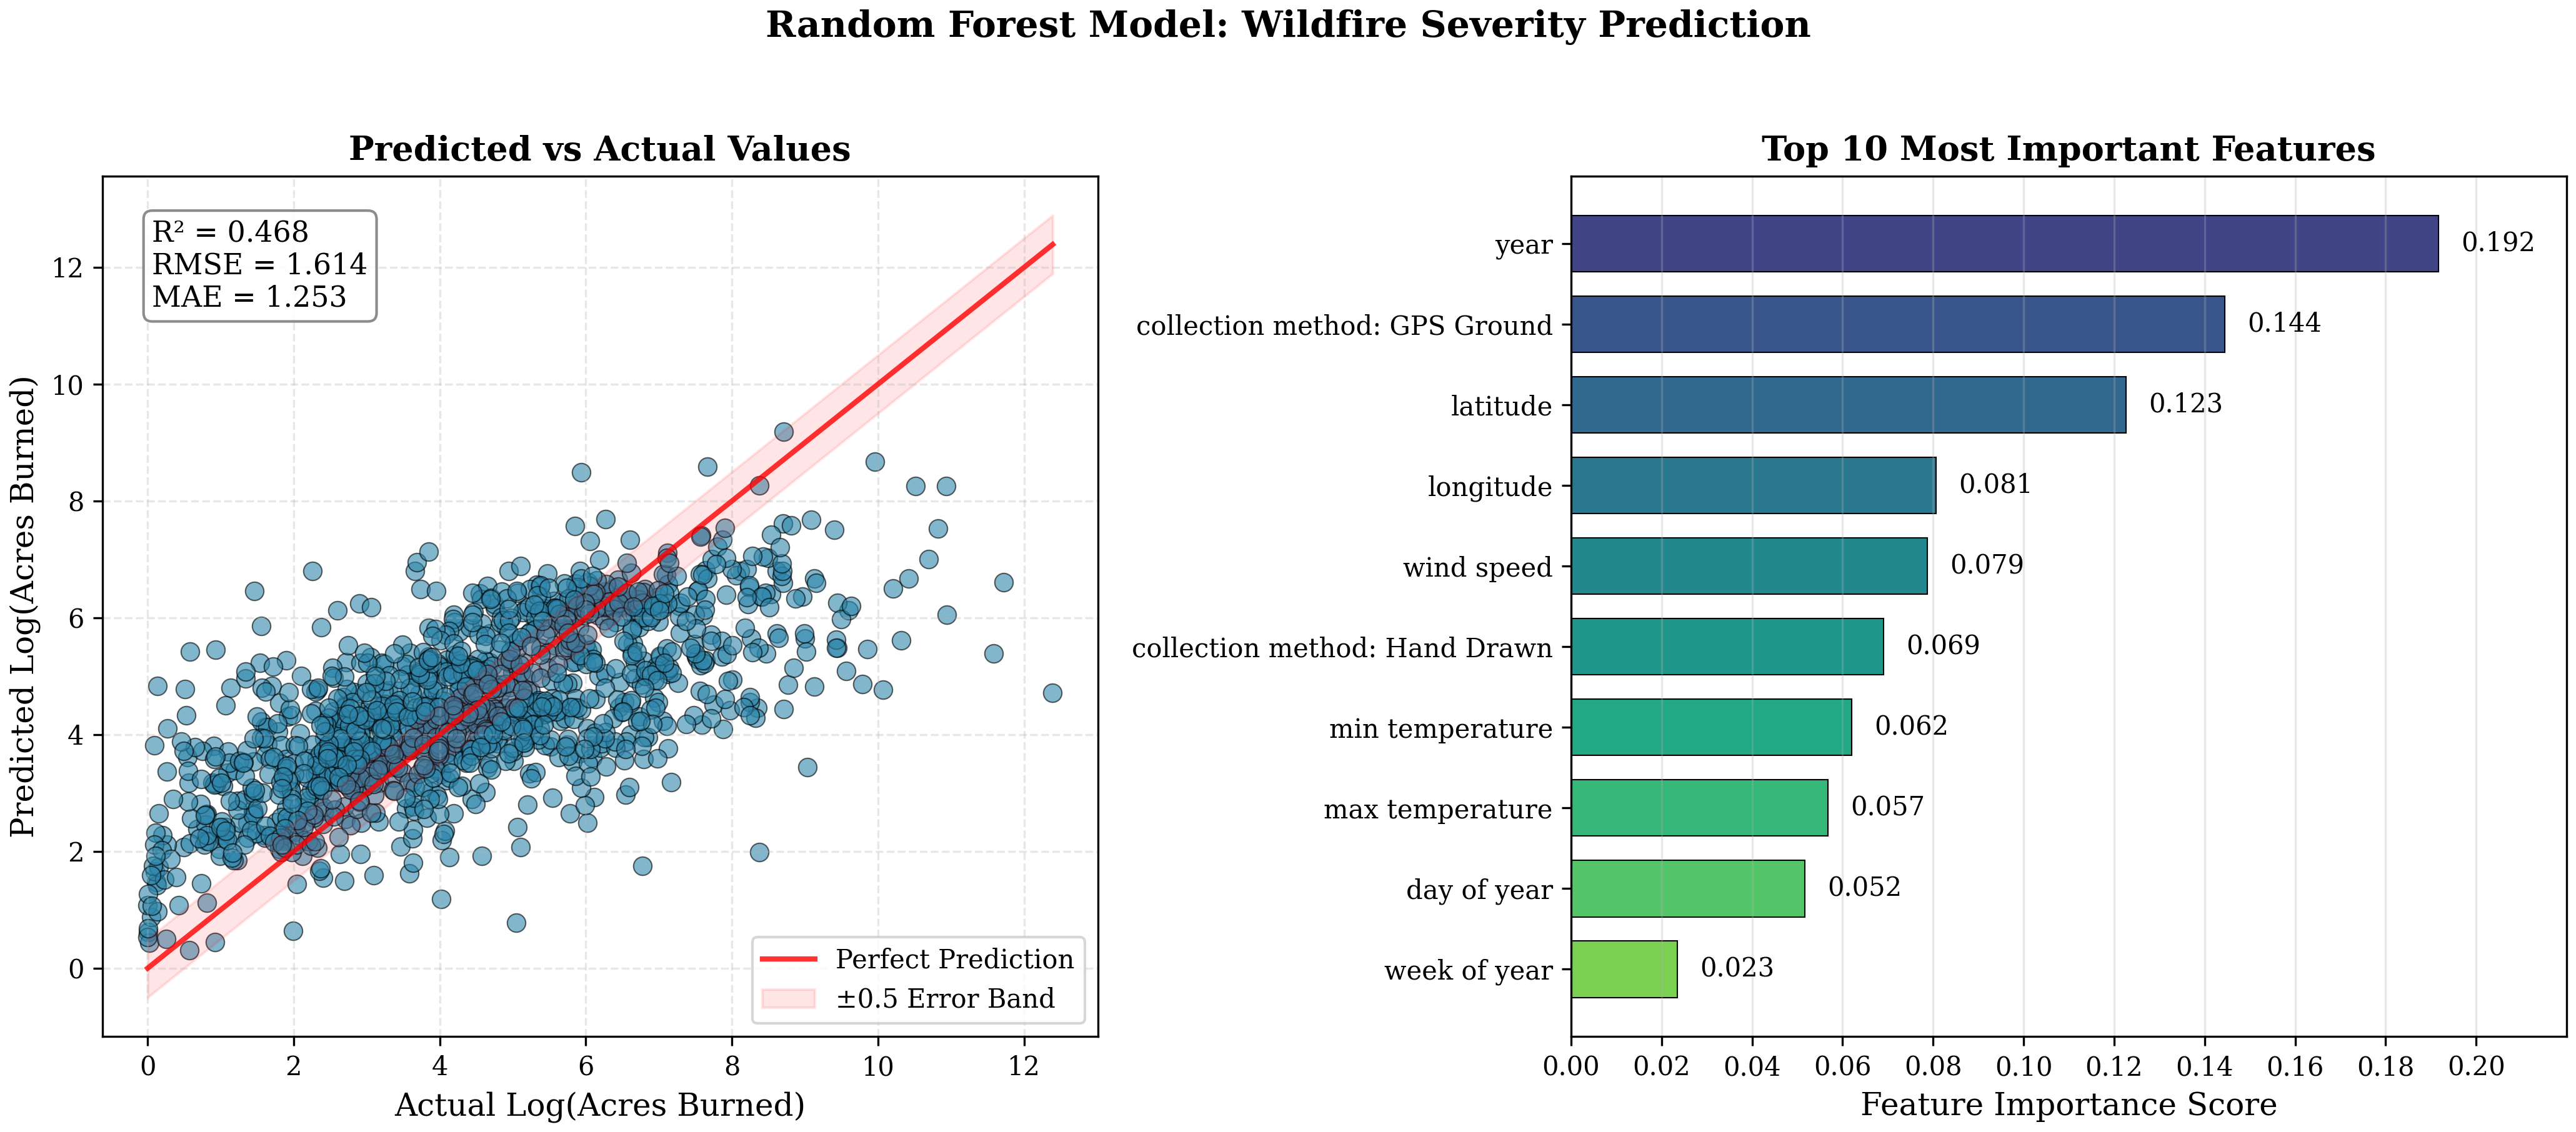

In [264]:
# Visualization with 2 subplots: Predicted vs Actual with performance metrics annotation, and Feature Importance bar chart with top features and their importance scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Random Forest Model: Wildfire Severity Prediction', fontsize=14, fontweight='bold', y=1.02)

# Get min and max values as floats
y_min = float(y_test.min())
y_max = float(y_test.max())

# Left Plot: Actual vs Predicted
ax1.scatter(y_test, y_pred_rf, alpha=0.6, s=50, c='#2E86AB', edgecolors='black', linewidth=0.5)
ax1.plot([y_min, y_max], [y_min, y_max], 'r-', lw=2, alpha=0.8, label='Perfect Prediction') # Add perfect prediction line

# Add ±0.5 error band (one standard deviation on log scale)
ax1.fill_between([y_min, y_max], 
                 [y_min - 0.5, y_max - 0.5], 
                 [y_min + 0.5, y_max + 0.5], 
                 alpha=0.1, color='red', label='±0.5 Error Band')

ax1.set_xlabel('Actual Log(Acres Burned)', fontsize=12)
ax1.set_ylabel('Predicted Log(Acres Burned)', fontsize=12)
ax1.set_title('Predicted vs Actual Values', fontsize=13, fontweight='bold')

# Add performance metrics annotation
rf_mae = mean_absolute_error(y_test, y_pred_rf)

# Legend and metrics annotation
annotation_text = f'R² = {rf_r2:.3f}\nRMSE = {rf_rmse:.3f}\nMAE = {rf_mae:.3f}'
ax1.text(0.05, 0.95, annotation_text, transform=ax1.transAxes, fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9))
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')

# Right plot: Feature Importance
# Get feature names after preprocessing
preprocessor = pipeline_rf.named_steps['preprocessor']
# Get names for numeric + categorical features
num_features = numerical_cols
cat_features = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols)
all_features = np.concatenate([num_features, cat_features])
# Get feature importances for plotting
importances = pipeline_rf.named_steps['rf'].feature_importances_

# Sort feature importance by top 10
feature_importance = pd.DataFrame({'feature': all_features, 'importance': importances}).sort_values('importance', ascending=True).tail(10)

# Map feature names to more readable labels
feature_importance['feature'] = feature_importance['feature'].replace({
    'lat': 'latitude',
    'wind_speed': 'wind speed',
    'collection_method_GPS Ground': 'collection method: GPS Ground',
    'lon': 'longitude',
    'temp_min': 'min temperature',
    'temp_max': 'max temperature',
    'collection_method_Hand Drawn': 'collection method: Hand Drawn',
    'day_of_year': 'day of year',
    'week': 'week of year'})

# Create horizontal bar chart
colors = plt.cm.viridis_r(np.linspace(0.2, 0.8, len(feature_importance)))
bars = ax2.barh(feature_importance['feature'], feature_importance['importance'], 
                color=colors, edgecolor='black', linewidth=0.5, height=0.7)
ax2.set_xlabel('Feature Importance Score', fontsize=12)
ax2.set_title('Top 10 Most Important Features', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
ax2.set_xlim(0, 0.22)
ax2.set_xticks(np.arange(0, 0.21, 0.02))

# Add value labels at the end of each bar
for i, (bar, val) in enumerate(zip(bars, feature_importance['importance'])):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', va='center', fontsize=10, fontweight='medium')

plt.tight_layout()
plt.show()

## Visualization rationale 

To visualize the results of the model, a scatter plot was created to compare the predicted values of acres burned against the actual values from the test set. This allows for a visual assessment of how well the model's predictions align with the true values. A line representing perfect predictions (where predicted equals actual) was added to the plot to help identify any deviations from perfect predictions. There is also a textbox including the model's r-squared, root mean squared error, and the mean absolute error to provide a quick reference for the model's performance metrics. Additionally, a bar chart was created to show which features had the most influence on the random forest model's predictions for acres burned. The choice of a bar chart for feature importance was made because it allows for easy comparison of the importance scores across different features, making it straightforward to identify the most influential predictors.